# Predicción de Afluencia del Metro de la Ciudad de México

## 1. Exploración preliminar del dataframe

In [70]:
# Importando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# Dataframe
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/refs/heads/main/Data/processed/afluencia_metro_2010_2025.zip'
df_raw = pd.read_csv(url,compression='zip')
df_raw.head()

,fecha,anio,linea,estacion,afluencia,mes_num,mes_nom
0,2010-01-01,2010,Línea 1,Zaragoza,20227,1,enero
1,2010-01-01,2010,Línea 1,Isabel la Católica,6487,1,enero
2,2010-01-01,2010,Línea 1,Moctezuma,10304,1,enero
3,2010-01-01,2010,Línea 1,Pino Suárez,8679,1,enero
4,2010-01-01,2010,Línea 1,Gómez Farías,19499,1,enero


### 1.1 Convertir fecha a ```datetime```

In [72]:
df = df_raw.copy()
df['fecha'] = pd.to_datetime(df['fecha'],errors='coerce')
df['fecha'].dtype

dtype('<M8[ns]')

### 1.2 Obtener día de la fecha

In [73]:
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()
df['dia_semana'] = df['dia_semana'].replace({
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado',
    'Sunday':'Domingo'
})
df['dia_semana'].unique()
df.head()

,fecha,anio,linea,estacion,afluencia,mes_num,mes_nom,dia,dia_semana
0,2010-01-01,2010,Línea 1,Zaragoza,20227,1,enero,1,Viernes
1,2010-01-01,2010,Línea 1,Isabel la Católica,6487,1,enero,1,Viernes
2,2010-01-01,2010,Línea 1,Moctezuma,10304,1,enero,1,Viernes
3,2010-01-01,2010,Línea 1,Pino Suárez,8679,1,enero,1,Viernes
4,2010-01-01,2010,Línea 1,Gómez Farías,19499,1,enero,1,Viernes


### 1.3 Correción en Meses

In [74]:
df['mes_nom'] = df['mes_nom'].replace({
    'enero':'Enero','febrero':'Febrero','marzo':'Marzo','abril':'Abril',
    'mayo':'Mayo','junio':'Junio','julio':'Julio','agosto':'Agosto',
    'septiembre':'Septiembre','octubre':'Octubre','noviembre':'Noviembre',
    'diciembre':'Diciembre'
})
df['mes_nom'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype=object)

In [75]:
# Colores del Metro
sns.set_theme(style='darkgrid')
metro_color = '#FE5000'
colores_metro = {
    'Línea 1':'#F04E98',
    'Línea 2':'#005EB8',
    'Línea 3':'#AF9800',
    'Línea 4':'#6BBBAE',
    'Línea 5':'#FFD100',
    'Línea 6':'#DA291C',
    'Línea 7':'#E87722',
    'Línea 8':'#009444',
    'Línea 9':'#512F2E',
    'Línea A':'#981D97',
    'Línea B':'#B1B3B3',
    'Línea 12':'#B0A32A'
}


## 2. Visualizaciones de las variables

In [76]:
# Copia del DataFrame para hacer visualizaciones
df_vis = df.copy()

# Orden Días de la semana
dias_semana = [
    'Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'
]

# Ordenando días de la semana
df_vis['dia_semana'] = pd.Categorical(
    df_vis['dia_semana'],
    categories=dias_semana,
    ordered=True
)
# Orden Meses
meses = [
    'Enero','Febrero','Marzo','Abril','Mayo','Junio',
    'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'
]

df_vis['mes_nom'] = pd.Categorical(
    df['mes_nom'],
    categories=meses,
    ordered=True
)

### 2.1 Variable Objetivo

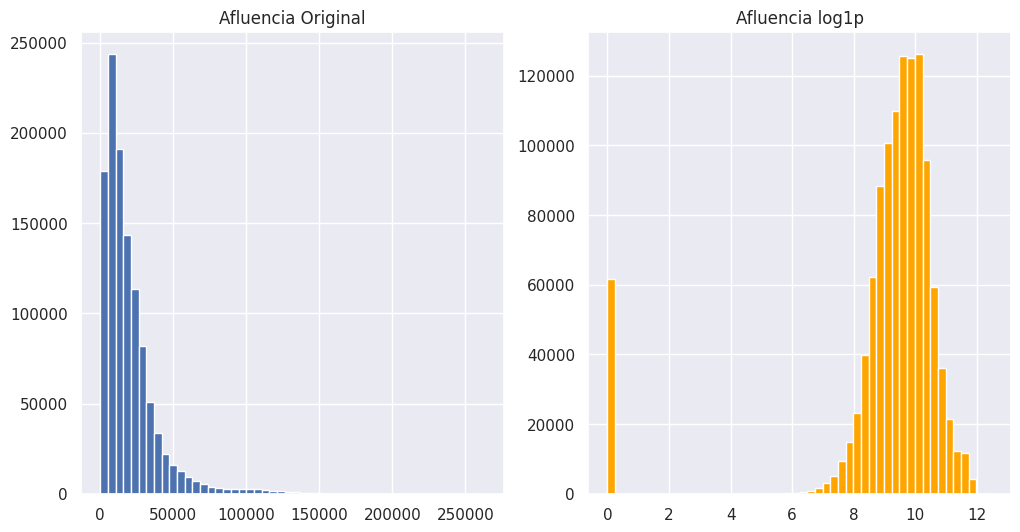

In [77]:
# Distribucción y skewness
fig, axes = plt.subplots(1,2,figsize=(12,6))
df_vis['afluencia'].hist(bins=50,ax=axes[0])
np.log1p(df_vis['afluencia']).hist(bins=50,ax=axes[1],color='orange')
axes[0].set_title('Afluencia Original')
axes[1].set_title('Afluencia log1p')
plt.show()

### 2.2 Variables Temporales

/tmp/ipykernel_727/4015777691.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis.groupby('dia_semana')['afluencia'].mean().plot(


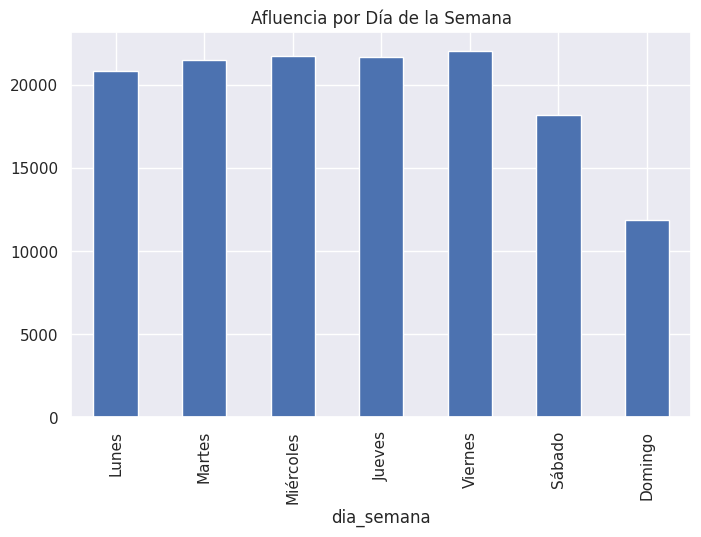

In [78]:
# Afluencia por Día de la semana
df_vis.groupby('dia_semana')['afluencia'].mean().plot(
    figsize=(8,5),
    kind='bar',
    title='Afluencia por Día de la Semana'
)
plt.show()

/tmp/ipykernel_727/2793960082.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis.groupby('mes_nom')['afluencia'].mean().plot(


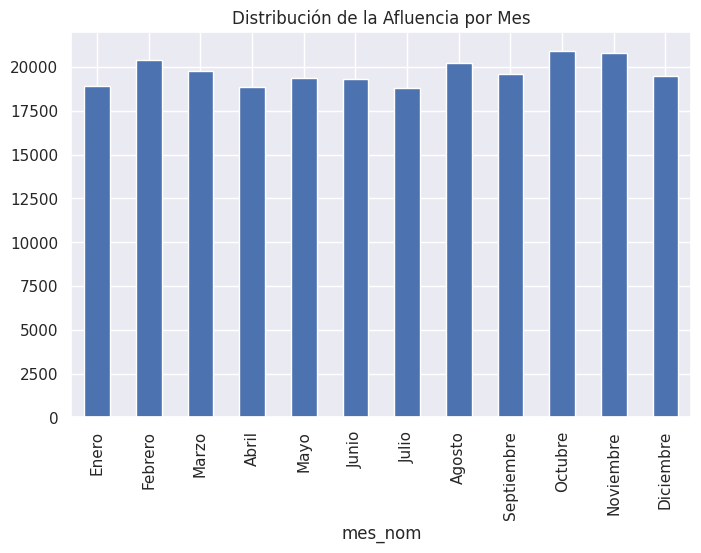

In [79]:
# Mes
df_vis.groupby('mes_nom')['afluencia'].mean().plot(
    figsize=(8,5),kind='bar',title='Distribución de la Afluencia por Mes')
plt.show()

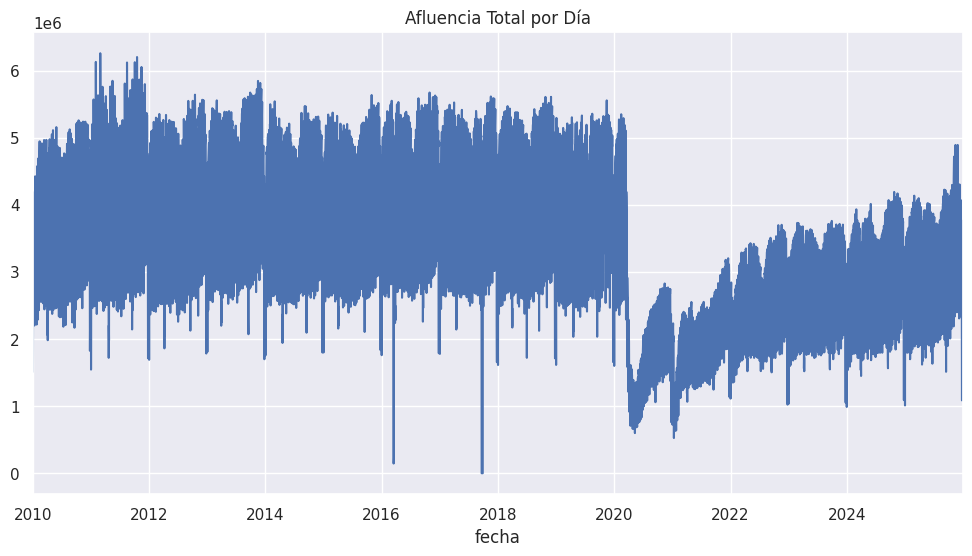

In [80]:
# Afluencia total
df_vis.groupby('fecha')['afluencia'].sum().plot(
    figsize=(12,6),title='Afluencia Total por Día')
plt.show()

/tmp/ipykernel_727/1716821469.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis.groupby(['dia_semana','mes_nom'])['afluencia'].mean().unstack()


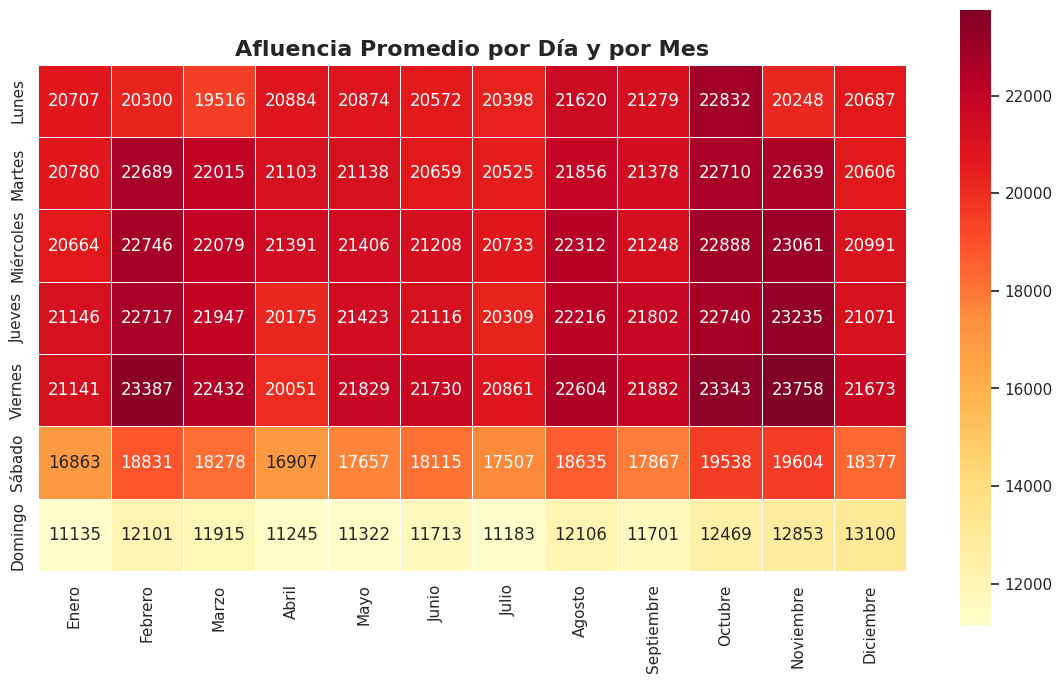

In [81]:
# Tabla Pivote
pivot = (
    df_vis.groupby(['dia_semana','mes_nom'])['afluencia'].mean().unstack()
)

# Visualizacion
plt.figure(figsize=(14,8))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True,
    linewidth=0.5,
    square=True,
    fmt='.0f'
)
plt.xlabel('')
plt.ylabel('')
plt.title('Afluencia Promedio por Día y por Mes',fontsize=16,fontweight='bold')
plt.show()

## 3. Sets de entrenamiento, validación y prueba

In [82]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor

### Trabajos previos

In [83]:
# Afluencia diaria por linea
df_lineas = (
    df.groupby(['fecha','linea'])['afluencia'].sum().reset_index()
)

# Conviertiendo linea a 'category'
df_lineas['linea'] = df_lineas['linea'].astype('category')

#### Feature Engineering

In [84]:
df_lineas['anio'] = df_lineas['fecha'].dt.year
df_lineas['mes'] = df_lineas['fecha'].dt.month
df_lineas['dia'] = df_lineas['fecha'].dt.day
df_lineas['dia_semana'] = df_lineas['fecha'].dt.day_of_week
df_lineas['dia_anio'] = df_lineas['fecha'].dt.dayofyear
df_lineas['es_fin_de_semana'] = (df_lineas['dia_semana'] >= 5).astype(int)
df_lineas.head()


,fecha,linea,afluencia,anio,mes,dia,dia_semana,dia_anio,es_fin_de_semana
0,2010-01-01,Línea 1,251474,2010,1,1,4,1,0
1,2010-01-01,Línea 12,0,2010,1,1,4,1,0
2,2010-01-01,Línea 2,285403,2010,1,1,4,1,0
3,2010-01-01,Línea 3,228261,2010,1,1,4,1,0
4,2010-01-01,Línea 4,24340,2010,1,1,4,1,0


### División de conjuntos de entrenamiento,validación y prueba

In [85]:
df_lineas = df_lineas.sort_values('fecha')
# Set de entrenamiento: Datos de entrenamiento de 2010 a 2023
train = df_lineas[df_lineas['fecha'] <'2024-01-01']
print(train.head(5))
print(train.tail(5))

        fecha    linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
0  2010-01-01  Línea 1     251474  2010    1    1           4         1   
11 2010-01-01  Línea B     191834  2010    1    1           4         1   
10 2010-01-01  Línea A      90993  2010    1    1           4         1   
9  2010-01-01  Línea 9      94283  2010    1    1           4         1   
7  2010-01-01  Línea 7      56191  2010    1    1           4         1   

    es_fin_de_semana  
0                  0  
11                 0  
10                 0  
9                  0  
7                  0  
           fecha     linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
61348 2023-12-31   Línea 4      29756  2023   12   31           6       365   
61347 2023-12-31   Línea 3     160070  2023   12   31           6       365   
61346 2023-12-31   Línea 2     214653  2023   12   31           6       365   
61345 2023-12-31  Línea 12      61010  2023   12   31           6       365   
61349 2023-12-31

In [86]:
# Set de Validacion: Datos de  2024
val = df_lineas[(df_lineas['fecha'] >= '2024-01-01') & (df_lineas['fecha'] < '2025-01-01')]

print(val.head(5))
print(val.tail(5))


           fecha    linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
61363 2024-01-01  Línea 7      47324  2024    1    1           0         1   
61366 2024-01-01  Línea A      76475  2024    1    1           0         1   
61365 2024-01-01  Línea 9      54958  2024    1    1           0         1   
61367 2024-01-01  Línea B     147541  2024    1    1           0         1   
61364 2024-01-01  Línea 8     107188  2024    1    1           0         1   

       es_fin_de_semana  
61363                 0  
61366                 0  
61365                 0  
61367                 0  
61364                 0  
           fecha     linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
65739 2024-12-31   Línea 3     291506  2024   12   31           1       366   
65738 2024-12-31   Línea 2     361417  2024   12   31           1       366   
65737 2024-12-31  Línea 12     198988  2024   12   31           1       366   
65736 2024-12-31   Línea 1     163877  2024   12   31      

In [87]:
# Set de Prueba: Datos de 2025
test  = df_lineas[df_lineas['fecha'] >= '2025-01-01']
print(test.head(5))
print(test.tail(5))

           fecha    linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
65759 2025-01-01  Línea B     122295  2025    1    1           2         1   
65758 2025-01-01  Línea A      79618  2025    1    1           2         1   
65757 2025-01-01  Línea 9      63290  2025    1    1           2         1   
65756 2025-01-01  Línea 8      96768  2025    1    1           2         1   
65755 2025-01-01  Línea 7      53497  2025    1    1           2         1   

       es_fin_de_semana  
65759                 0  
65758                 0  
65757                 0  
65756                 0  
65755                 0  
           fecha     linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
70117 2025-12-31  Línea 12     215923  2025   12   31           2       365   
70116 2025-12-31   Línea 1     319037  2025   12   31           2       365   
70126 2025-12-31   Línea A     175938  2025   12   31           2       365   
70120 2025-12-31   Línea 4      49946  2025   12   31      

In [88]:
# Tamaño de los sets
print(train.shape, val.shape, test.shape)

(61356, 9) (4392, 9) (4380, 9)


### OneHotEncoder

In [89]:
# Encoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

encoder.fit(train[['linea']])
train_encoded = encoder.transform(train[['linea']])
val_encoded = encoder.transform(val[['linea']])
test_encoded = encoder.transform(test[['linea']])

# Nombre de columnas
columnas = encoder.get_feature_names_out(['linea'])


In [90]:
# Convirtiendo a DF

train_encoded = pd.DataFrame(
    train_encoded,columns=columnas,index=train.index
)
val_encoded = pd.DataFrame(
    val_encoded,columns=columnas,index=val.index
)
test_encoded = pd.DataFrame(
    test_encoded,columns=columnas,index=test.index
)

# Concatenar
train = pd.concat([train.drop(columns=['linea']),train_encoded],axis=1)
val   = pd.concat([val.drop(columns=['linea']), val_encoded], axis=1)
test  = pd.concat([test.drop(columns=['linea']), test_encoded], axis=1)

# Tamaño
print("Tamaño de entrenamiento",train.shape)
print("Tamaño de validacion",val.shape)
print("Tamaño de prueba",test.shape)

Tamaño de entrenamiento (61356, 20)
Tamaño de validacion (4392, 20)
Tamaño de prueba (4380, 20)


### Variables predictoras y objetivo

In [91]:
features = ['anio','mes','dia','dia_semana','dia_anio','es_fin_de_semana']
features += [col for col in train.columns if col.startswith('linea_')]

# Entrenamiento
X_train = train[features]
y_train = train['afluencia']

# Validacion
X_val = val[features]
y_val = val['afluencia']
# Prueba
X_test = test[features]
y_test = test['afluencia']

print('X_train tamaño', X_train.shape)
print('y_train tamaño', y_train.shape)
print('X_val tamaño', X_val.shape)
print('y_val tamaño', y_val.shape)
print('X_test tamaño', X_test.shape)
print('y_test tamaño', y_test.shape)

X_train tamaño (61356, 18)
y_train tamaño (61356,)
X_val tamaño (4392, 18)
y_val tamaño (4392,)
X_test tamaño (4380, 18)
y_test tamaño (4380,)


In [92]:
X_train.columns

Index(['anio', 'mes', 'dia', 'dia_semana', 'dia_anio', 'es_fin_de_semana',
       'linea_Línea 1', 'linea_Línea 12', 'linea_Línea 2', 'linea_Línea 3',
       'linea_Línea 4', 'linea_Línea 5', 'linea_Línea 6', 'linea_Línea 7',
       'linea_Línea 8', 'linea_Línea 9', 'linea_Línea A', 'linea_Línea B'],
      dtype='object')

### Modelo

In [93]:
model1 = XGBRegressor(
    n_estimators = 2000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=10,
    early_stopping_rounds=50,
    random_state=42
)
# Entrenar
model1.fit(
    X_train,
    y_train,
    eval_set=[(X_val,y_val)],
    verbose=False
)
print("Mejor iteración:",model1.best_iteration)

Mejor iteración: 218


In [94]:
# Predicción
y_val_pred = model1.predict(X_val)

# Evaluacion para Validación
mae_val = mean_absolute_error(y_val,y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val,y_val_pred))
r2_val = r2_score(y_val,y_val_pred)

print(f" MAE: {mae_val:.2f} | RMSE: {rmse_val:.2f} | R²: {r2_val:.3f}")

 MAE: 37659.35 | RMSE: 59496.90 | R²: 0.861


In [146]:
# Predicción
y_test_pred = model1.predict(X_test)

# Evaluacion para Validación
mae_test = mean_absolute_error(y_test,y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))
r2_test = r2_score(y_test,y_test_pred)

print(f" MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.3f}")

# Guardar predicciones
test['prediccion'] = y_test_pred

 MAE: 49890.53 | RMSE: 82505.92 | R²: 0.743


## 4. Visualizaciones

### Scatter plot real vs predicho

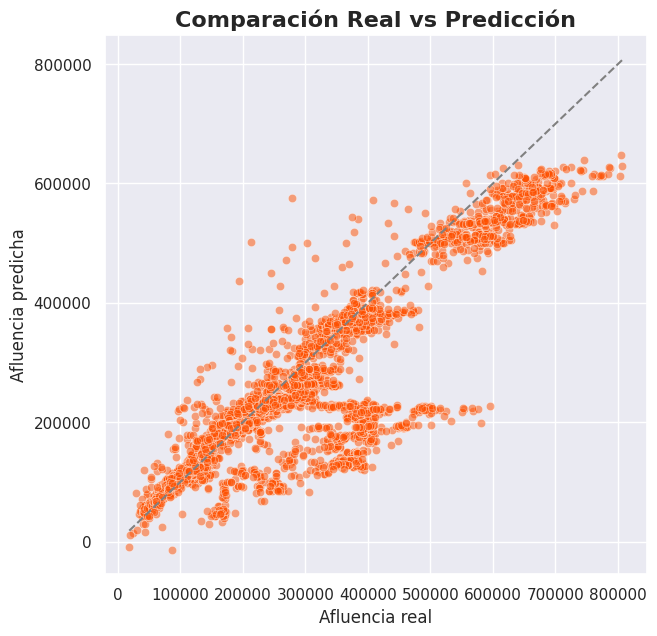

In [97]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, color="#fe5000")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='gray')
plt.xlabel("Afluencia real")
plt.ylabel("Afluencia predicha")
plt.title("Comparación Real vs Predicción",fontsize=16,fontweight='bold')
plt.show()

### Gráfico de errores

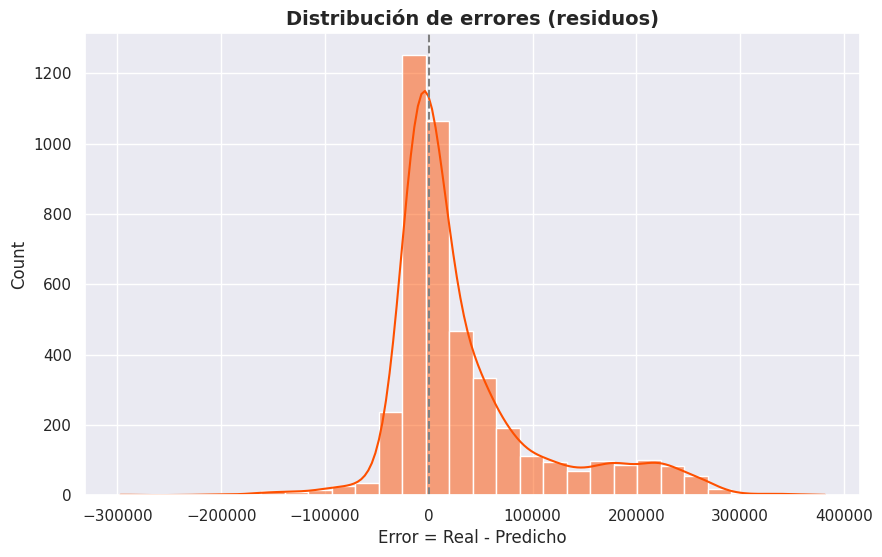

In [98]:
residuos = y_test - y_test_pred
plt.figure(figsize=(10,6))
sns.histplot(
    residuos,
    bins=30,
    kde=True,
    color='#FE5000'
)
plt.axvline(0,color='gray',linestyle='--')
plt.xlabel('Error = Real - Predicho')
plt.title('Distribución de errores (residuos)',fontsize=14,fontweight='bold')
plt.show()

### Barplot de error medio absoluto (MAE) por línea

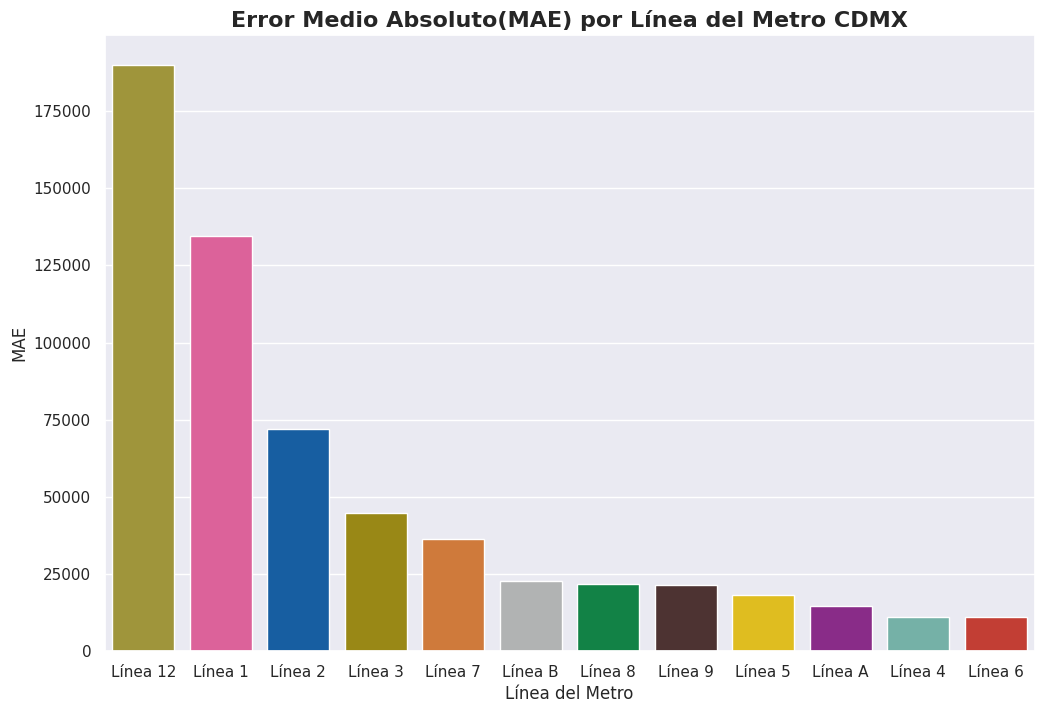

In [99]:
test_df = X_test.copy()
test_df['real'] = y_test
test_df['pred'] = y_test_pred
cols_lineas = [c for c in test_df.columns if c.startswith('linea_')]
test_df['linea'] = test_df[cols_lineas].idxmax(axis=1).str.replace('linea_','')

test_df['error_abs'] = abs(test_df['real']-test_df['pred'])

mae_por_linea = (
    test_df
    .groupby('linea')['error_abs']
    .mean().sort_values(ascending=False)
)
plt.figure(figsize=(12,8))
sns.barplot(
    x=mae_por_linea.index,
    y=mae_por_linea.values,
    palette=colores_metro,
    hue=mae_por_linea.index
)
plt.title('Error Medio Absoluto(MAE) por Línea del Metro CDMX',fontsize=16,
          fontweight='bold')
plt.ylabel('MAE')
plt.xlabel('Línea del Metro')
plt.show()

### Real vs Predicho por Línea

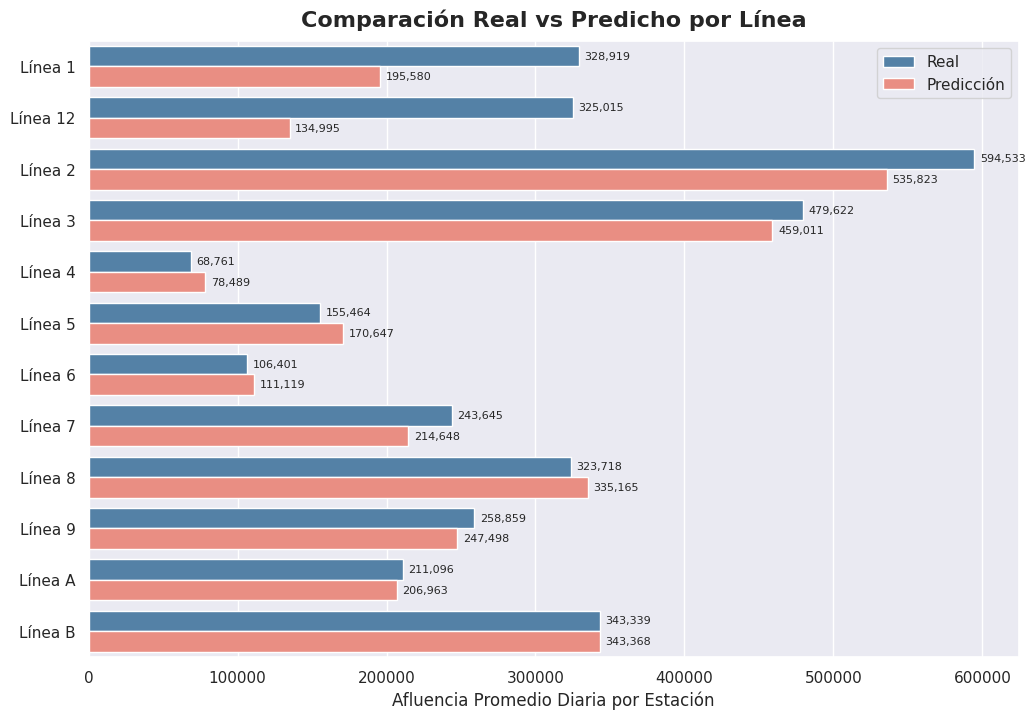

In [100]:
import matplotlib.ticker as mticker
comparacion_linea = (
    test_df
    .groupby('linea')[['real','pred']]
    .mean().reset_index()
)
comparacion_linea_melt = comparacion_linea.melt(
    id_vars='linea',
    value_vars=['real','pred'],
    var_name='Tipo',
    value_name='Afluencia'
)

plt.figure(figsize=(12,8))
ax = sns.barplot(
    data=comparacion_linea_melt,
    y='linea',
    x='Afluencia',
    hue='Tipo',
    palette={'real':'steelblue','pred':'salmon'},
    orient='h',
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Real','Predicción'],
    title=''
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}',padding=4,fontsize=8)
plt.xlabel('Afluencia Promedio Diaria por Estación')
plt.ylabel('')
plt.title('Comparación Real vs Predicho por Línea',fontsize=16,fontweight='bold',
          pad=10)
plt.show()

### Gráfico de Dispersión (Real vs Predicho)

#### Scatter General

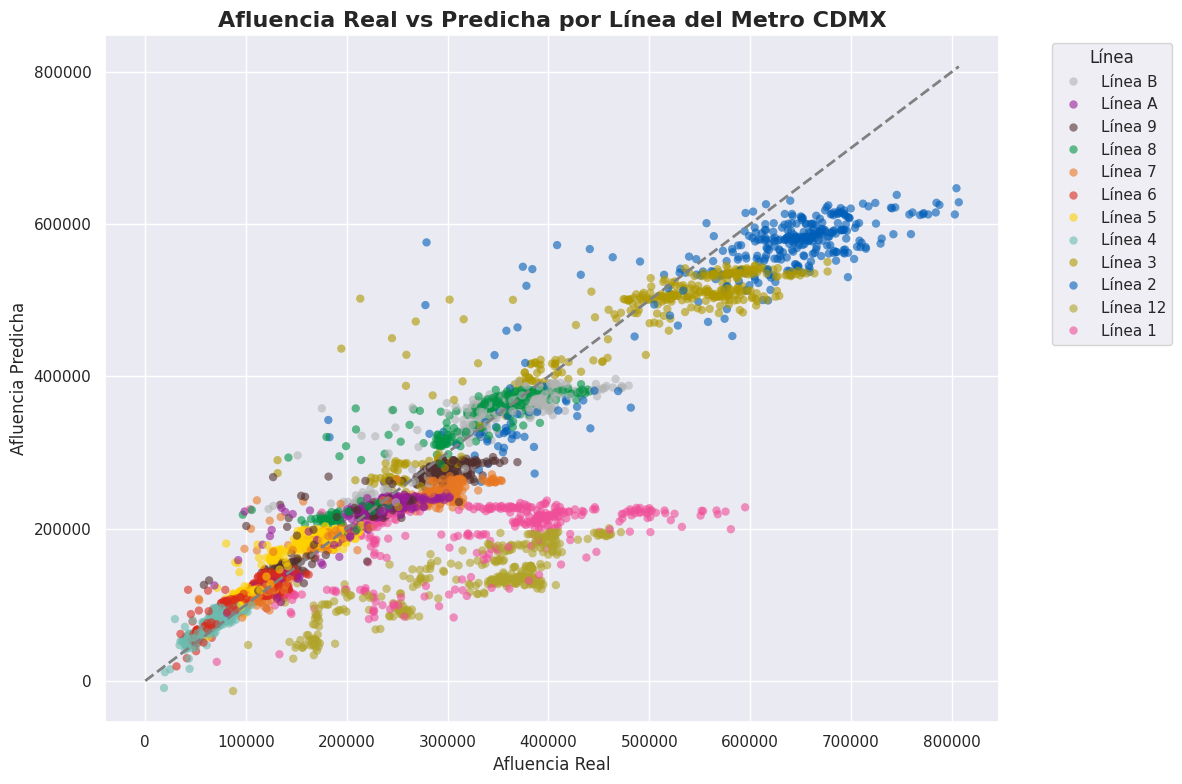

In [101]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=test_df,
    x='real',
    y='pred',
    hue='linea',
    palette=colores_metro,
    alpha=0.6,
    edgecolor='none'
)

# Diagonal ideal (perfect prediction)
max_val = max(test_df['real'].max(), test_df['pred'].max())
plt.plot([0, max_val], [0, max_val], '--', color='gray', lw=2)

plt.title('Afluencia Real vs Predicha por Línea del Metro CDMX', fontsize=16, fontweight='bold')
plt.xlabel('Afluencia Real')
plt.ylabel('Afluencia Predicha')
plt.legend(title='Línea', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Subplots

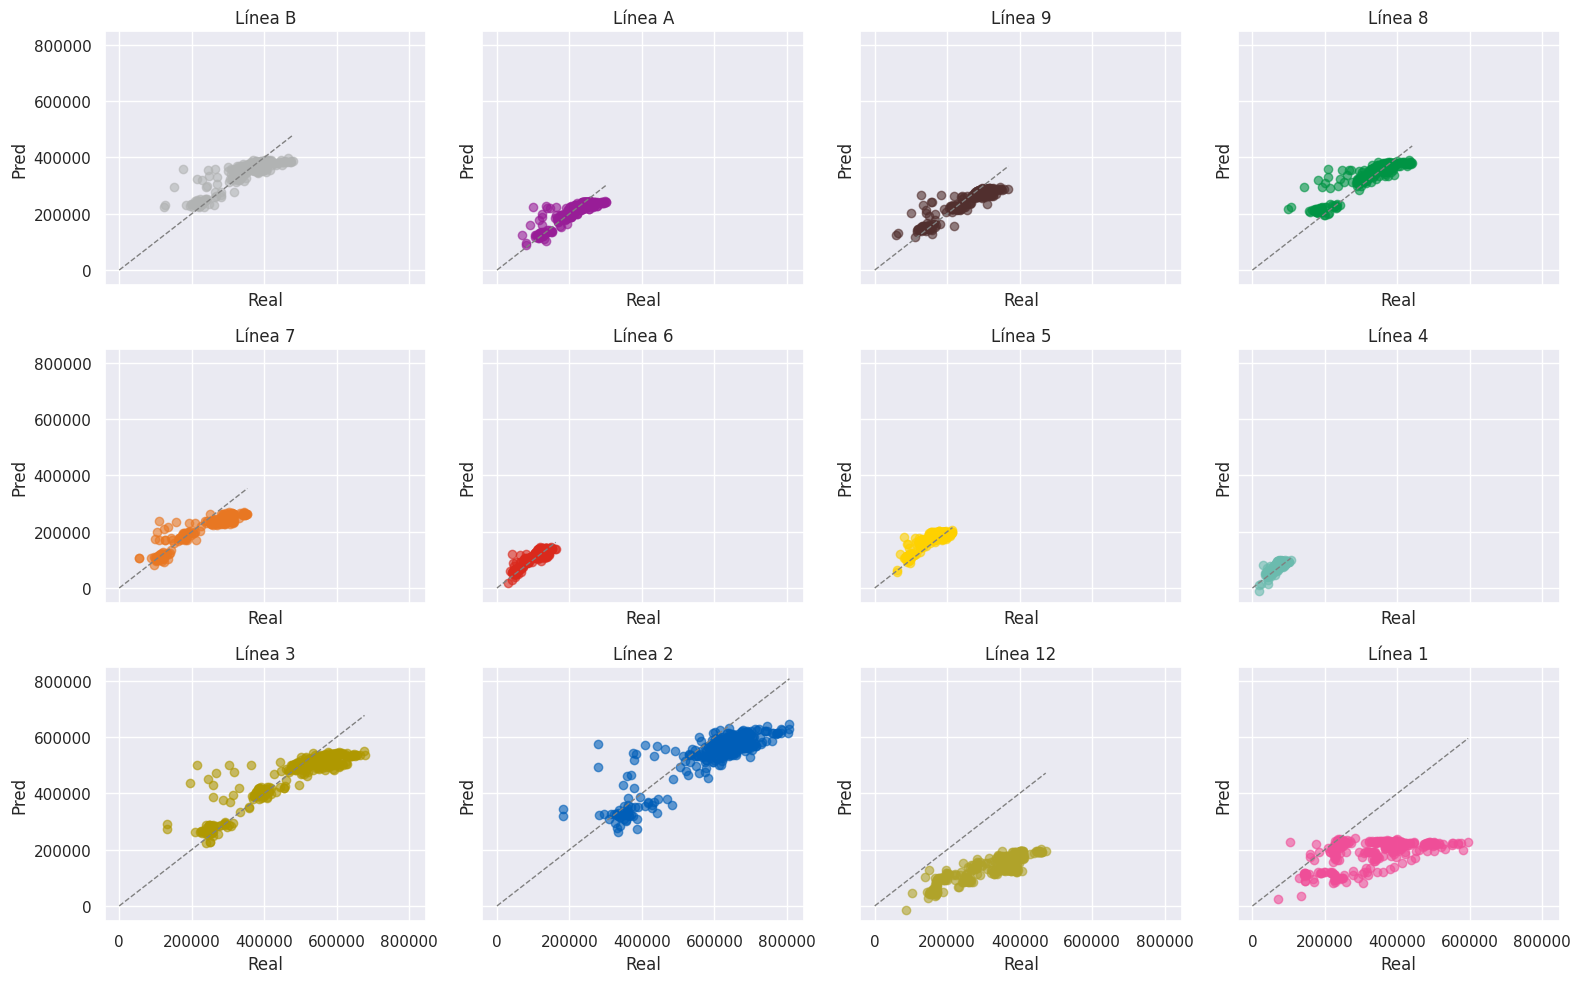

In [102]:
lineas = test_df['linea'].unique()
n = len(lineas)
cols = 4
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, linea in enumerate(lineas):
    subset = test_df[test_df['linea'] == linea]
    axes[i].scatter(subset['real'], subset['pred'], color=colores_metro.get(linea, '#999999'), alpha=0.6)
    axes[i].plot([0, subset['real'].max()], [0, subset['real'].max()], '--', color='gray', lw=1)
    axes[i].set_title(linea)
    axes[i].set_xlabel('Real')
    axes[i].set_ylabel('Pred')

plt.tight_layout()
plt.show()


/tmp/ipykernel_727/1666219147.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: r2_score(df['real'], df['pred']))


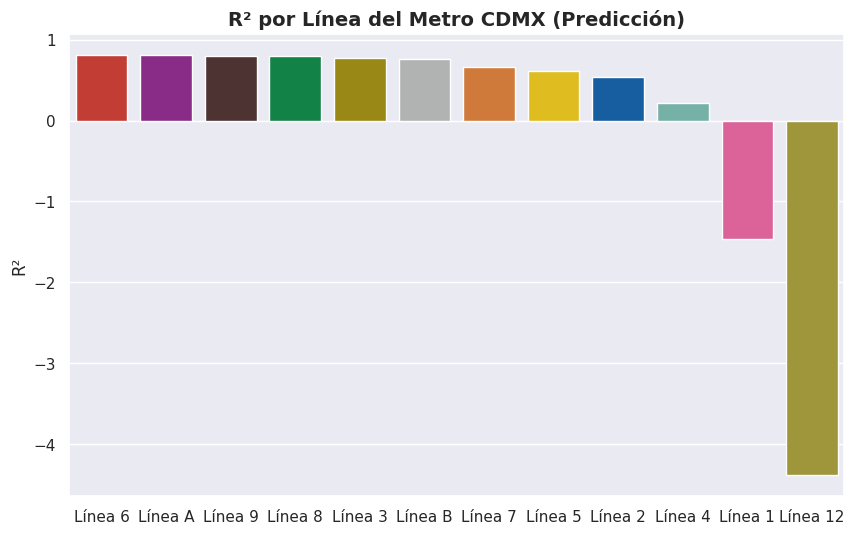

In [103]:
r2_por_linea = (
    test_df.groupby('linea')
          .apply(lambda df: r2_score(df['real'], df['pred']))
          .sort_values(ascending=False)
)

r2_por_linea = r2_por_linea.reset_index(name='R2')
plt.figure(figsize=(10,6))
sns.barplot(
    data=r2_por_linea,
    x='linea',
    y='R2',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('')
plt.ylabel('R²')
plt.title('R² por Línea del Metro CDMX (Predicción)',fontsize=14,fontweight='bold')
plt.show()

## 5. Modelo 2

### Normalizando variable objetivo

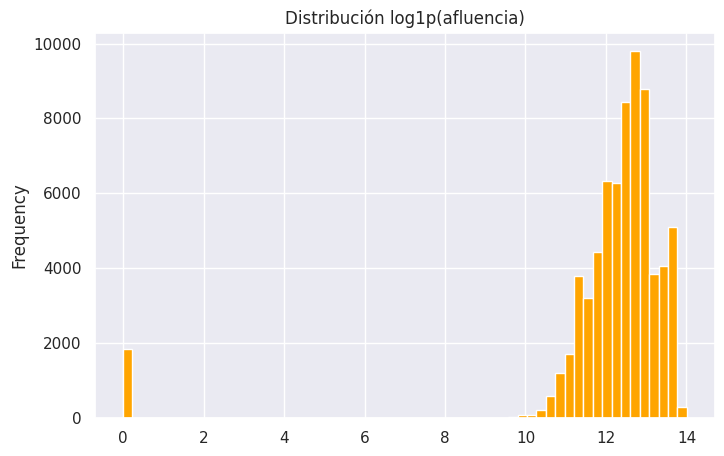

In [104]:
# Normalizar variable objetivo
df_modelo2 = df_lineas.copy()
df_modelo2['afluencia_log'] = np.log1p(df_modelo2['afluencia'])

plt.figure(figsize=(8,5))
df_modelo2['afluencia_log'].plot(kind='hist',bins=60,color='orange',
                                title='Distribución log1p(afluencia)')
plt.show()

### Agregando días festivos

In [105]:
import holidays
mx_holidays = holidays.Mexico(years=range(2010,2026))
# Fechas a datetime
fechas_feriado = pd.to_datetime(list(mx_holidays.keys()))
df_modelo2['es_feriado'] = df_modelo2['fecha'].isin(fechas_feriado).astype(int)


### Variables cíclicas, Lag Features y Rolling Windows

Como mes y día de la semana son variables circulares, habrá que modelar esa característica.

In [106]:
# Variables cícliclas
df_modelo2['mes_sin'] = np.sin(2*np.pi*df_modelo2['mes']/12)
df_modelo2['mes_cos'] = np.cos(2*np.pi*df_modelo2['mes']/12)

df_modelo2['dia_semana_sin'] = np.sin(2*np.pi*df_modelo2['dia_semana']/7)
df_modelo2['dia_semana_cos'] = np.cos(2*np.pi*df_modelo2['dia_semana']/7)

df_modelo2['dia_sin'] = np.sin(2*np.pi*df_modelo2['dia_semana']/31)
df_modelo2['dia_cos'] = np.cos(2*np.pi*df_modelo2['dia_semana']/31)
# Lag Features
df_modelo2 = df_modelo2.sort_values(['linea','fecha'])

df_modelo2['lag1'] = df_modelo2.groupby('linea')['afluencia_log'].shift(1)
df_modelo2['lag7']= df_modelo2.groupby('linea')['afluencia_log'].shift(7)
df_modelo2['lag14']= df_modelo2.groupby('linea')['afluencia_log'].shift(14)
df_modelo2['lag28']= df_modelo2.groupby('linea')['afluencia_log'].shift(28)

df_modelo2['rolling7'] = (
    df_modelo2.groupby('linea')['afluencia_log']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)
df_modelo2['rolling14'] = (
    df_modelo2.groupby('linea')['afluencia_log']
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

df_modelo2['rolling30'] = (
    df_modelo2.groupby('linea')['afluencia_log']
    .transform(lambda x: x.shift(1).rolling(30).mean()))

/tmp/ipykernel_727/1746815084.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo2['lag1'] = df_modelo2.groupby('linea')['afluencia_log'].shift(1)
/tmp/ipykernel_727/1746815084.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo2['lag7']= df_modelo2.groupby('linea')['afluencia_log'].shift(7)
/tmp/ipykernel_727/1746815084.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo2['lag14']= df_mo

### Sets de Entrenamiento y Prueba

In [125]:
# Set de Entrenamiento: 2010 a 2023
train2 = df_modelo2[df_modelo2['fecha'] <'2024-01-01']

# Set de Validacion: 2024
val2 = df_modelo2[(df_modelo2['fecha'] >= '2024-01-01') & (df_modelo2['fecha'] < '2025-01-01')]

# Set de Prueba: Datos de 2025
test2 = df_modelo2[df_modelo2['fecha'] >= '2025-01-01']

### One Hot Encoding

In [126]:
# Enconder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder.fit(train2[['linea']])
train_encoded2 = encoder.transform(train2[['linea']])
val_encoded2 = encoder.transform(val2[['linea']])
test_encoded2 = encoder.transform(test2[['linea']])

# Nombres de columnas
columnas = encoder.get_feature_names_out(['linea'])

# Conviertiendo a DF
train_encoded2 = pd.DataFrame(
    train_encoded2,columns=columnas,index=train2.index
)

val_encoded2 = pd.DataFrame(
    val_encoded2,columns=columnas,index=val2.index
)

test_encoded2 = pd.DataFrame(
    test_encoded2,columns=columnas,index=test2.index
)

# Concatenar
train_2 = pd.concat([train2.drop(columns=['linea']),train_encoded2],axis=1)
val_2 = pd.concat([val2.drop(columns=['linea']), val_encoded2], axis=1)
test_2 = pd.concat([test2.drop(columns=['linea']), test_encoded2], axis=1)

# Tamaño
print("Tamaño de entrenamiento",train_2.shape)
print("Tamaño de validacion",val_2.shape)
print("Tamaño de prueba",test_2.shape)

Tamaño de entrenamiento (61356, 35)
Tamaño de validacion (4392, 35)
Tamaño de prueba (4380, 35)


### Variables predictoras y objetivo

In [136]:
features = ['anio','mes','dia','dia_semana','dia_anio','es_fin_de_semana','es_feriado',
            'mes_sin','mes_cos','dia_semana_sin','dia_semana_cos','dia_sin','dia_cos','lag1',
            'lag7','lag14','lag28','rolling7','rolling14','rolling30']
features += [c for c in train_2.columns if c.startswith('linea_')]

# Entrenamiento
X_train_2 = train_2[features]
y_train_2 = train_2['afluencia']

# Validacion
X_val_2 = val_2[features]
y_val_2 = val_2['afluencia']
# Prueba
X_test_2 = test_2[features]
y_test_2 = test_2['afluencia']

print('X_train tamaño', X_train_2.shape)
print('y_train tamaño', y_train_2.shape)
print('X_val tamaño', X_val_2.shape)
print('y_val tamaño', y_val_2.shape)
print('X_test tamaño', X_test_2.shape)
print('y_test tamaño', y_test_2.shape)

X_train tamaño (61356, 32)
y_train tamaño (61356,)
X_val tamaño (4392, 32)
y_val tamaño (4392,)
X_test tamaño (4380, 32)
y_test tamaño (4380,)


### Modelo 2

In [137]:
model2 = XGBRegressor(
    n_estimators = 2000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=10,
    early_stopping_rounds=50,
    random_state=42
)

# Entrenar
model2.fit(
    X_train_2,
    y_train_2,
    eval_set = [(X_val_2,y_val_2)],
    verbose=False
)
print("Mejor iteración:",model2.best_iteration)

Mejor iteración: 950


In [138]:
# Predicción para validacion
y_val_pred2 = model2.predict(X_val_2)

# Evaluacion para Validacion
mae_val2 = mean_absolute_error(y_val_2,y_val_pred2)
rmse_val2 = np.sqrt(mean_squared_error(y_val_2,y_val_pred2))
r2_val2 = r2_score(y_val_2,y_val_pred2)
print(f" MAE: {mae_val2:.2f} | RMSE: {rmse_val2:.2f} | R²: {r2_val2:.3f}")

 MAE: 11991.17 | RMSE: 19717.27 | R²: 0.985


In [160]:
# Predicción para test
y_test_pred2 = model2.predict(X_test_2)

# Evaluacion para Validación
mae_test2 = mean_absolute_error(y_test_2,y_test_pred2)
rmse_test2 = np.sqrt(mean_squared_error(y_test_2,y_test_pred2))
r2_test2 = r2_score(y_test_2,y_test_pred2)

print(f" MAE: {mae_test2:.2f} | RMSE: {rmse_test2:.2f} | R²: {r2_test2:.3f}")
# Guardar predicciones
test_2['pred'] = y_test_pred2

 MAE: 12805.42 | RMSE: 21680.97 | R²: 0.982


### Visualizaciones

In [161]:
# Copia
test_df = test_2.copy()
# Reconstruyendo lineas
linea_cols = [c for c in test_df.columns if c.startswith('linea_')]
test_df['linea'] = test_df[linea_cols].idxmax(axis=1).str.replace('linea_','')

# Real
test_df['real'] = test_df['afluencia']

#### Feature Importance

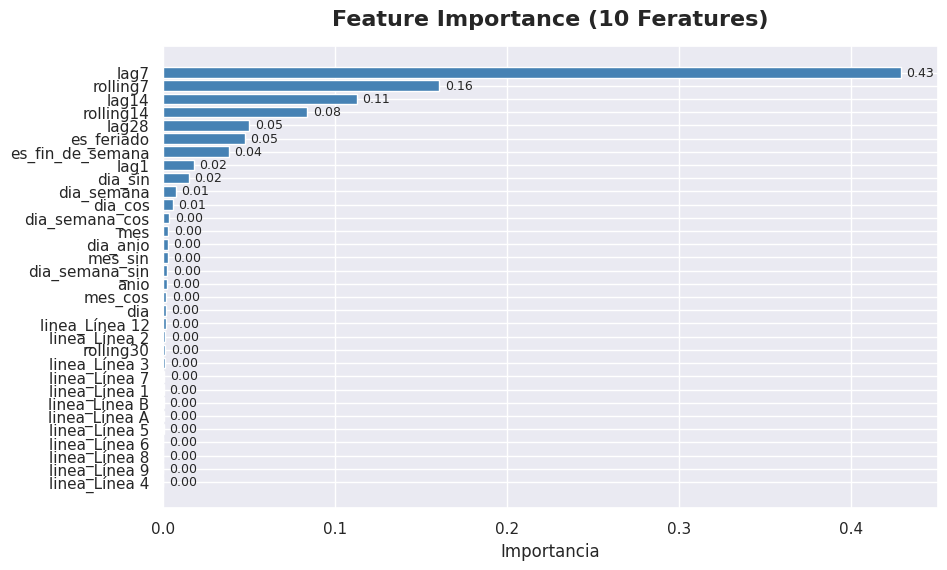

In [186]:
# Importances
importances = model2.feature_importances_

# Pasar a dataframe
fi_df = pd.DataFrame({
    'feature':features,
    'importance':importances
}).sort_values('importance',ascending=True)

# Visualizacion
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(
    fi_df['feature'],fi_df['importance'],color='steelblue'
)
ax.bar_label(bars, fmt='{:.2f}', padding=4, fontsize=9)
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance (10 Feratures)',fontsize=16,fontweight='bold',pad=15)
plt.show()

#### Error por Línea

/tmp/ipykernel_727/784775235.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.abs((g['real']-g['pred'])/g['real']))*100)


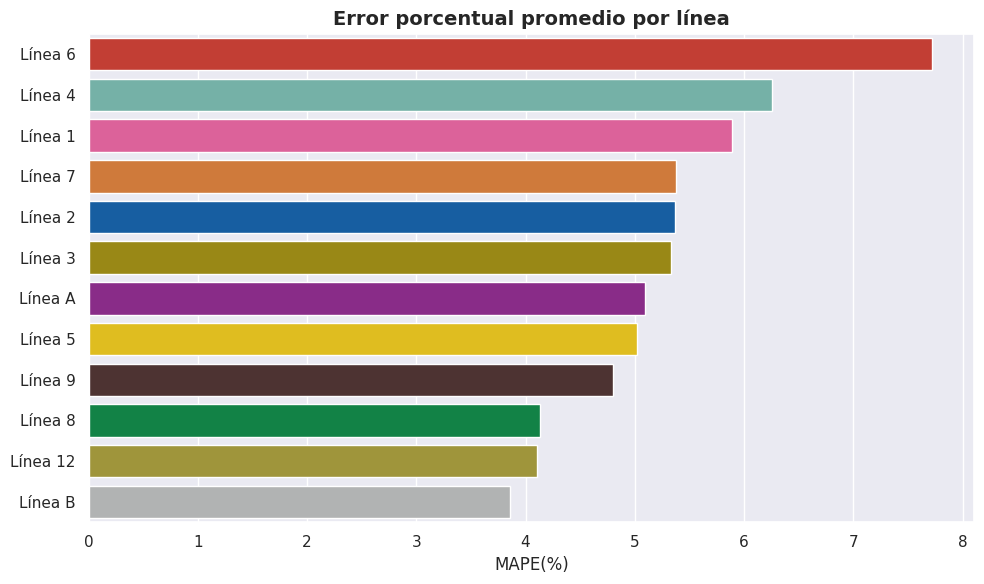

In [174]:
mape_linea = (
    test_df
    .groupby('linea')
    .apply(lambda g: np.mean(np.abs((g['real']-g['pred'])/g['real']))*100)
    .reset_index(name='MAPE')
    .sort_values('MAPE',ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))
bars = sns.barplot(
    data=mape_linea,
    y='linea',
    x='MAPE',
    palette=colores_metro,
    hue='linea'
)
ax.set_xlabel('MAPE(%)')
ax.set_ylabel('')
ax.set_title('Error porcentual promedio por línea',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

#### Real vs Predicho


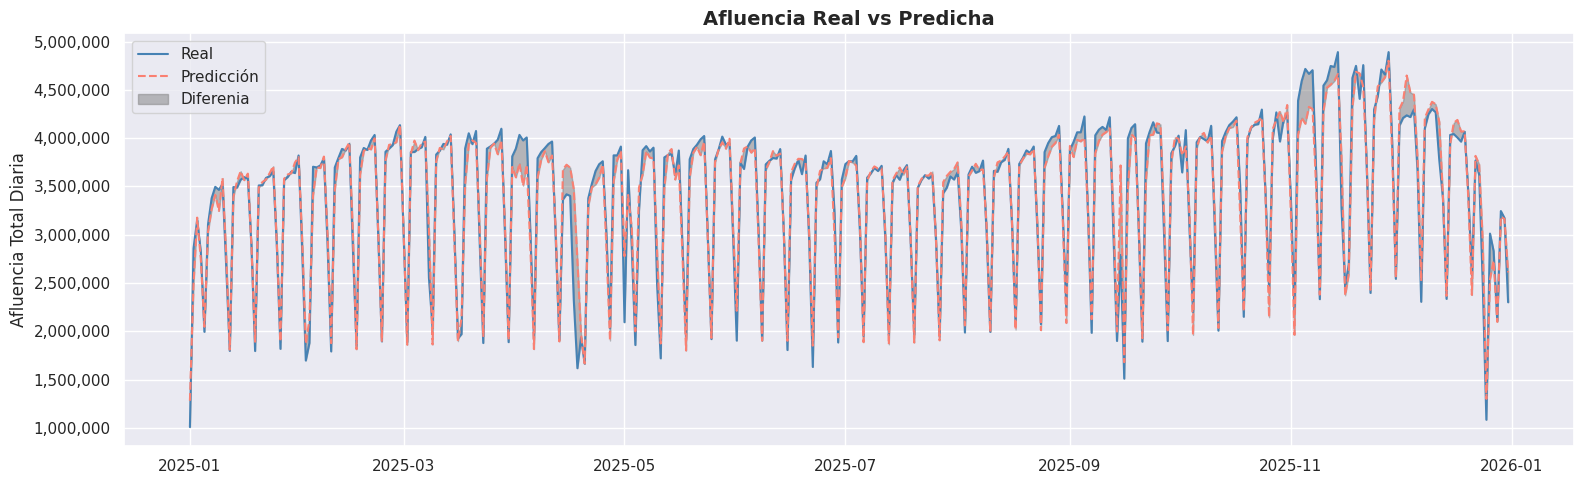

In [205]:
tiempo_df = (
    test_df
    .groupby('fecha')[['real','pred']]
    .sum()
    .reset_index()
    .sort_values('fecha')
)
plt.figure(figsize=(16,5))
# Afluencia Real
plt.plot(
    tiempo_df['fecha'],
    tiempo_df['real'],
    label='Real',
    color='steelblue',
    linewidth=1.5
)
# Afluencia Predicha
plt.plot(
    tiempo_df['fecha'],
    tiempo_df['pred'],
    label='Predicción',
    color='salmon',
    linewidth=1.5,
    linestyle='--'
)

# Diferencia
plt.fill_between(
    tiempo_df['fecha'],
    tiempo_df['real'],
    tiempo_df['pred'],
    alpha=0.5,color='gray',label='Diferenia'
)
plt.xlabel('')
plt.ylabel('Afluencia Total Diaria')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('Afluencia Real vs Predicha',fontsize=14,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

#### Distribución de residuales

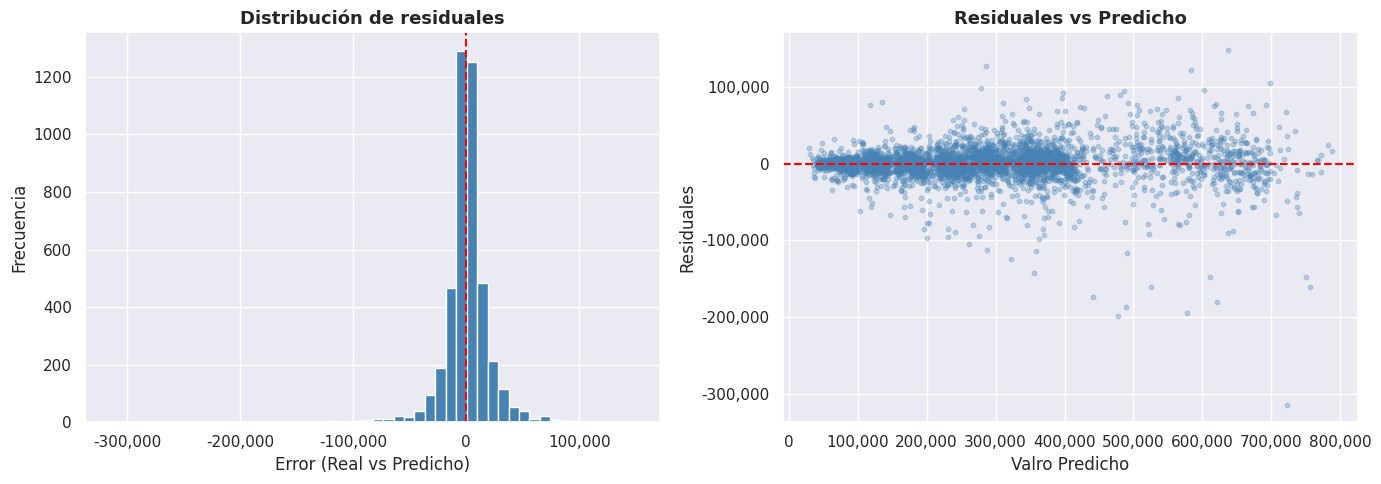

In [221]:
test_df['residual'] = test_df['real'] - test_df['pred']
fig,axes = plt.subplots(1,2,figsize=(14,5))

# Histograma
axes[0].hist(test_df['residual'],bins=50,color='steelblue',edgecolor='white')
axes[0].axvline(0,color='red',linestyle='--',linewidth=1.5)
axes[0].set_title('Distribución de residuales',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Error (Real vs Predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Residuales vs Predicho
axes[1].scatter(
    test_df['pred'],test_df['residual'],alpha=0.3,s=10,color='steelblue'
)
axes[1].axhline(0,color='red',linestyle='--',linewidth=1.5)
axes[1].set_title('Residuales vs Predicho',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Valro Predicho')
axes[1].set_ylabel('Residuales')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## Predicciones de Afluencia para 2026